# IVF Optimization Lab

Laboratório para otimização dos parâmetros do Inverted File Index (IVF) antes de gerar os arquivos binários para a API Go.

**Objetivo**: Explicabilidade de como `n_clusters`, `batch_size` e `nprobe` afetam recall@5, latência e qualidade da busca.

**Contexto**: A API Go atual faz KNN brute-force com k=5 e threshold=0.6. O IVF vai substituir o brute-force para reduzir latência.

In [13]:
from pathlib import Path

import gzip
import ijson
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from scipy.spatial.distance import cdist
from sklearn.cluster import MiniBatchKMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)

K_NEIGHBORS = 5          # mesmo k do Go (knn.go)
FRAUD_THRESHOLD = 0.6    # mesmo threshold do Go
RANDOM_STATE = 42
N_SAMPLE = 100_000       # amostras do dataset (evita carregar 320 MB)
VAL_SIZE = 10_000        # queries de validação

print("Imports OK")

Imports OK


## 1. Carregamento completo do dataset

3M records × 14 dims ≈ 320 MB em float64 — cabe na memória sem problemas.

In [14]:
_cwd = Path.cwd()
_candidates = [
    _cwd / "data" / "references.json.gz",
    _cwd.parent / "data" / "references.json.gz",
]
DATA_PATH = next((p for p in _candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("references.json.gz não encontrado")

# Reservoir sampling: lê o stream sem carregar tudo na memória
print(f"Amostrando {N_SAMPLE:,} registros de {DATA_PATH} ...")
t0 = time.time()

rng = np.random.default_rng(RANDOM_STATE)
bucket_vecs: list[np.ndarray] = []
bucket_labels: list[bool] = []
n_seen = 0

with gzip.open(DATA_PATH, "rb") as f:
    for obj in ijson.items(f, "item"):
        n_seen += 1
        vec = np.asarray(obj["vector"], dtype=np.float64)
        fraud = obj.get("label") == "fraud"
        if len(bucket_vecs) < N_SAMPLE:
            bucket_vecs.append(vec)
            bucket_labels.append(fraud)
        else:
            j = int(rng.integers(0, n_seen))
            if j < N_SAMPLE:
                bucket_vecs[j] = vec
                bucket_labels[j] = fraud

vectors = np.stack(bucket_vecs)
labels = np.array(bucket_labels, dtype=bool)
del bucket_vecs, bucket_labels

print(f"Carregado em {time.time() - t0:.1f}s  ({n_seen:,} registros vistos, {N_SAMPLE:,} amostrados)")
print(f"Shape: {vectors.shape}, Fraudes: {labels.sum()} ({100 * labels.mean():.2f}%)")
print(f"Memória: {vectors.nbytes / 1024**2:.1f} MB")

Amostrando 100,000 registros de /home/luiz/hobbies/rbc-2026/data/references.json.gz ...
Carregado em 30.5s  (3,000,000 registros vistos, 100,000 amostrados)
Shape: (100000, 14), Fraudes: 33333 (33.33%)
Memória: 10.7 MB


## 2. Split train/val + Ground Truth (Brute Force)

Calcula os 5 vizinhos mais próximos via brute-force para cada query de validação. Esse é o "gabarito" contra o qual medimos o recall do IVF.

In [15]:
# Separa um conjunto de validação
idx_all = np.arange(len(vectors))
idx_train, idx_val = train_test_split(
    idx_all, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=labels
)

X_train = vectors[idx_train]
y_train = labels[idx_train]
X_val = vectors[idx_val]
y_val = labels[idx_val]

print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Fraudes train: {y_train.sum()} ({100*y_train.mean():.2f}%)")
print(f"Fraudes val:   {y_val.sum()} ({100*y_val.mean():.2f}%)")

# Ground truth: brute-force KNN nos dados de treino
print("\nCalculando ground truth (brute-force KNN)...")
t0 = time.time()
bf = NearestNeighbors(n_neighbors=K_NEIGHBORS, algorithm="brute", metric="euclidean", n_jobs=-1)
bf.fit(X_train)
gt_dists, gt_indices = bf.kneighbors(X_val)
print(f"Ground truth calculado em {time.time() - t0:.1f}s")

# Ground truth para classificação: score = fração de vizinhos fraudulentos
gt_fraud_counts = np.array([y_train[gt_indices[i]].sum() for i in range(len(X_val))])
gt_scores = gt_fraud_counts / K_NEIGHBORS
gt_approved = gt_scores < FRAUD_THRESHOLD
print(f"Brute-force: {(~gt_approved).sum()} rejeitados de {len(X_val)} queries ({100*(~gt_approved).mean():.2f}%)")

Train: (90000, 14), Val: (10000, 14)
Fraudes train: 30000 (33.33%)
Fraudes val:   3333 (33.33%)

Calculando ground truth (brute-force KNN)...
Ground truth calculado em 0.7s
Brute-force: 3339 rejeitados de 10000 queries (33.39%)


## 3. Classe IVFExperiment

Simula exatamente o que o Go fará:
1. K-Means para quantização grosseira (centroides)
2. Lista invertida (posting lists)
3. Busca: seleciona `nprobe` centroides mais próximos → brute-force local nos candidatos

In [16]:
class IVFExperiment:
    """Simula busca IVF como implementada na API Go."""

    def __init__(self, X_train, y_train, X_val, gt_indices):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.gt_indices = gt_indices

    def build_index(self, n_clusters, batch_size, n_init=3):
        """Treina K-Means e constrói listas invertidas."""
        self.kmeans = MiniBatchKMeans(
            n_clusters=n_clusters,
            batch_size=batch_size,
            n_init=n_init,
            random_state=RANDOM_STATE,
        )
        self.kmeans.fit(self.X_train)
        self.centroids = self.kmeans.cluster_centers_

        cluster_labels = self.kmeans.labels_
        self.inverted_lists = {
            c: np.where(cluster_labels == c)[0] for c in range(n_clusters)
        }

        sizes = [len(v) for v in self.inverted_lists.values()]
        return {
            "n_clusters": n_clusters,
            "inertia": self.kmeans.inertia_,
            "list_size_mean": np.mean(sizes),
            "list_size_std": np.std(sizes),
            "list_size_min": np.min(sizes),
            "list_size_max": np.max(sizes),
        }

    def search(self, nprobe, k=K_NEIGHBORS):
        """Busca IVF — distâncias aos centroides vetorizadas (cdist)."""
        centroids = self.centroids
        inv = self.inverted_lists
        X_train = self.X_train
        X_val = self.X_val
        gt = self.gt_indices

        # Todas as distâncias query→centroide de uma vez (n_val × n_clusters)
        dists_matrix = cdist(X_val, centroids)

        total_recall = 0.0
        total_candidates = 0
        start = time.perf_counter()

        for i in range(len(X_val)):
            nearest_c = np.argpartition(dists_matrix[i], nprobe)[:nprobe]
            candidate_ids = np.concatenate([inv[c] for c in nearest_c])
            total_candidates += len(candidate_ids)

            if len(candidate_ids) == 0:
                continue

            local_dists = np.linalg.norm(X_train[candidate_ids] - X_val[i], axis=1)
            top_k_local = candidate_ids[np.argpartition(local_dists, min(k, len(local_dists) - 1))[:k]]

            hits = len(np.intersect1d(top_k_local, gt[i]))
            total_recall += hits / k

        elapsed = time.perf_counter() - start
        n_queries = len(X_val)
        return {
            "recall_at_k": total_recall / n_queries,
            "latency_ms": 1000 * elapsed / n_queries,
            "avg_candidates": total_candidates / n_queries,
        }

    def evaluate_classification(self, nprobe, k=K_NEIGHBORS):
        """Avalia impacto na decisão de fraude vs brute-force."""
        centroids = self.centroids
        inv = self.inverted_lists
        X_train = self.X_train
        y_train = self.y_train
        X_val = self.X_val

        dists_matrix = cdist(X_val, centroids)
        ivf_approved = np.zeros(len(X_val), dtype=bool)

        for i in range(len(X_val)):
            nearest_c = np.argpartition(dists_matrix[i], nprobe)[:nprobe]
            candidate_ids = np.concatenate([inv[c] for c in nearest_c])

            if len(candidate_ids) == 0:
                ivf_approved[i] = True
                continue

            local_dists = np.linalg.norm(X_train[candidate_ids] - X_val[i], axis=1)
            top_k_local = candidate_ids[np.argpartition(local_dists, min(k, len(local_dists) - 1))[:k]]

            ivf_approved[i] = y_train[top_k_local].sum() / k < FRAUD_THRESHOLD

        agreement = (ivf_approved == gt_approved).mean()
        return {
            "decision_agreement": agreement,
            "ivf_rejected": int((~ivf_approved).sum()),
            "bf_rejected": int((~gt_approved).sum()),
        }


experiment = IVFExperiment(X_train, y_train, X_val, gt_indices)
print("IVFExperiment pronto.")

IVFExperiment pronto.


## 4. Optuna — Otimização de hiperparâmetros

Busca multiobjetivo: **maximizar recall@5** e **minimizar latência**.

O Optuna nos dá importância dos hiperparâmetros automaticamente.

In [18]:
def objective(trial):
    n_clusters = trial.suggest_int("n_clusters", 32, 2048, log=True)
    batch_size = trial.suggest_categorical("batch_size", [1024, 2048, 4096, 8192])
    nprobe = trial.suggest_int("nprobe", 1, min(50, n_clusters))

    experiment.build_index(n_clusters, batch_size)
    res = experiment.search(nprobe)

    trial.set_user_attr("avg_candidates", res["avg_candidates"])

    return res["recall_at_k"], res["latency_ms"]


study = optuna.create_study(
    directions=["maximize", "minimize"],
    study_name="ivf_optimization",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True),
)

N_TRIALS = 30
print(f"Iniciando {N_TRIALS} trials...")
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)  # n_jobs=1: experiment não é thread-safe
print(f"Otimização concluída em {time.time() - t0:.1f}s")
print(f"Trials na fronteira de Pareto: {len(study.best_trials)}")

/tmp/ipykernel_135620/754333960.py:17: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE, multivariate=True),


Iniciando 30 trials...


 33%|███▎      | 10/30 [03:21<05:20, 16.04s/it]

[W 2026-05-07 15:10:30,502] The parameter `nprobe` in Trial#10 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


 37%|███▋      | 11/30 [03:29<04:18, 13.62s/it]

...

[W 2026-05-07 15:11:34,770] The parameter `nprobe` in Trial#28 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


 97%|█████████▋| 29/30 [04:27<00:02,  2.46s/it]

[W 2026-05-07 15:11:35,902] The parameter `nprobe` in Trial#29 is sampled independently using `RandomSampler` instead of `TPESampler`, potentially degrading the optimization performance. This fallback happend because dynamic search space is not supported for `multivariate=True`. You can suppress this warning by setting `warn_independent_sampling` to `False` in the constructor of `TPESampler` if this independent sampling is intended behavior.


100%|██████████| 30/30 [04:44<00:00,  9.50s/it]

Otimização concluída em 284.9s
Trials na fronteira de Pareto: 12


## 5. Explicabilidade — Importância dos parâmetros

Qual parâmetro mais influencia recall? E latência?

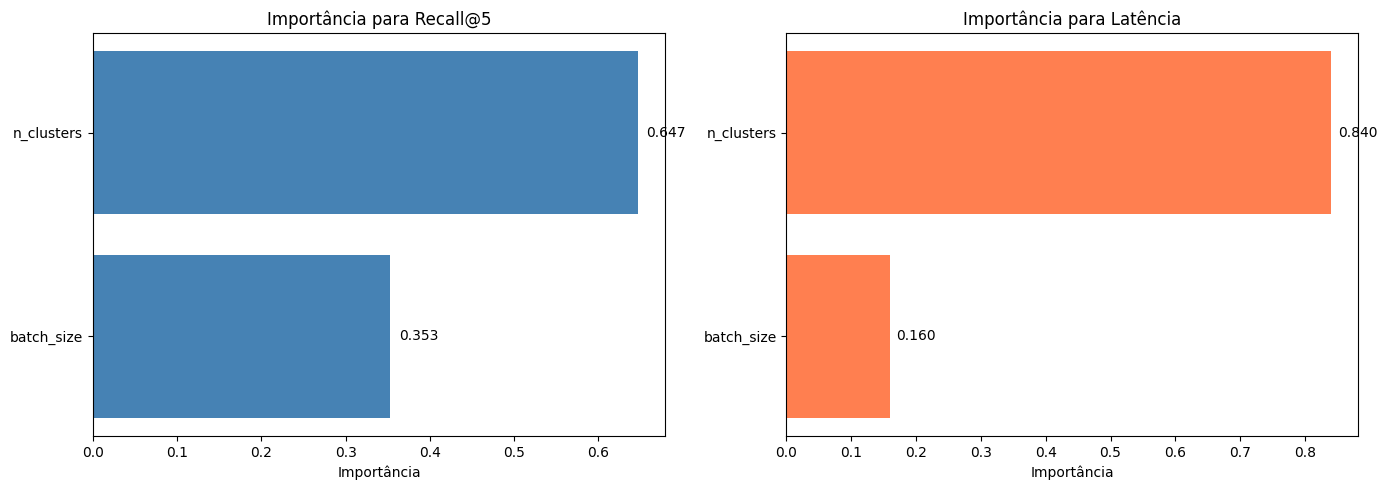


--- Importância Recall@5 ---
  n_clusters: 0.6469
  batch_size: 0.3531

--- Importância Latência ---
  n_clusters: 0.8402
  batch_size: 0.1598


In [19]:
# Importância dos hiperparâmetros por objetivo
importance_recall = optuna.importance.get_param_importances(study, target=lambda t: t.values[0])
importance_latency = optuna.importance.get_param_importances(study, target=lambda t: t.values[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

params = list(importance_recall.keys())
vals_r = list(importance_recall.values())
axes[0].barh(params, vals_r, color="steelblue")
axes[0].set_xlabel("Importância")
axes[0].set_title("Importância para Recall@5")
axes[0].invert_yaxis()
for i, v in enumerate(vals_r):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center")

params = list(importance_latency.keys())
vals_l = list(importance_latency.values())
axes[1].barh(params, vals_l, color="coral")
axes[1].set_xlabel("Importância")
axes[1].set_title("Importância para Latência")
axes[1].invert_yaxis()
for i, v in enumerate(vals_l):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

print("\n--- Importância Recall@5 ---")
for p, v in importance_recall.items():
    print(f"  {p}: {v:.4f}")

print("\n--- Importância Latência ---")
for p, v in importance_latency.items():
    print(f"  {p}: {v:.4f}")

## 6. Fronteira de Pareto — Trade-off recall vs latência

In [20]:
# Todos os trials
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "trial": t.number,
            "n_clusters": t.params["n_clusters"],
            "batch_size": t.params["batch_size"],
            "nprobe": t.params["nprobe"],
            "recall_at_5": t.values[0],
            "latency_ms": t.values[1],
            "avg_candidates": t.user_attrs.get("avg_candidates", 0),
            "pareto": t in study.best_trials,
        })

df_trials = pd.DataFrame(trials_data)

fig = px.scatter(
    df_trials,
    x="latency_ms",
    y="recall_at_5",
    color="pareto",
    size="n_clusters",
    hover_data=["n_clusters", "batch_size", "nprobe", "avg_candidates"],
    title="Fronteira de Pareto — Recall@5 vs Latência",
    labels={"latency_ms": "Latência (ms/query)", "recall_at_5": "Recall@5"},
    color_discrete_map={True: "red", False: "lightgray"},
    template="plotly_white",
)
fig.update_layout(height=500)
fig.show()

# Tabela dos pontos na fronteira de Pareto
df_pareto = df_trials[df_trials["pareto"]].sort_values("recall_at_5", ascending=False)
print("\nFronteira de Pareto (ordenado por recall):")
df_pareto[["n_clusters", "batch_size", "nprobe", "recall_at_5", "latency_ms", "avg_candidates"]]

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## 7. Contour plots — Interação entre parâmetros

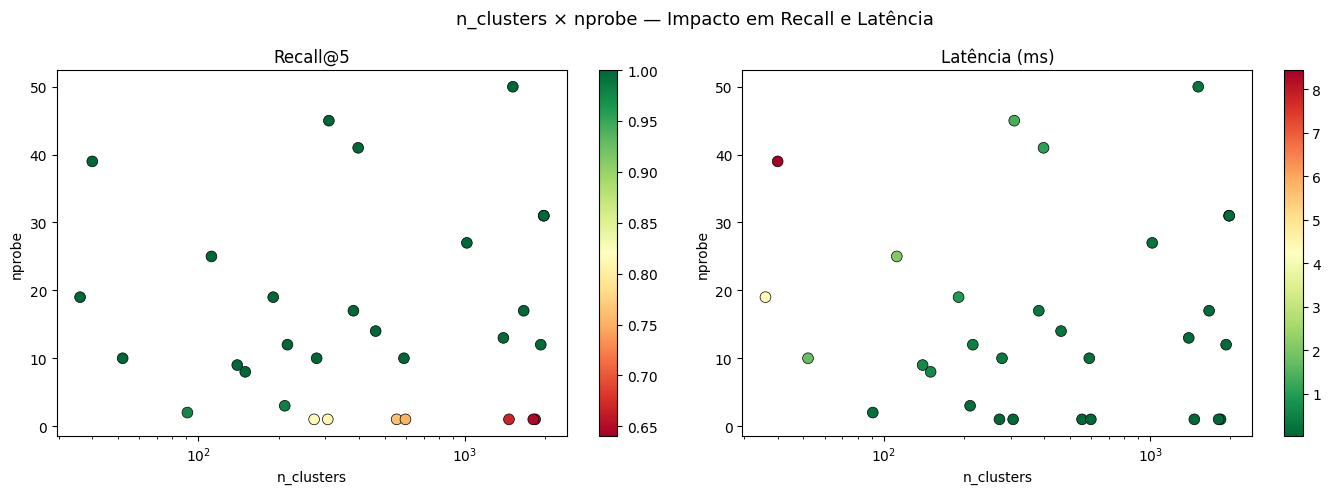

In [21]:
# Contour plots para recall e latência
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_complete = df_trials[df_trials["recall_at_5"] > 0].copy()

sc0 = axes[0].scatter(
    df_complete["n_clusters"],
    df_complete["nprobe"],
    c=df_complete["recall_at_5"],
    cmap="RdYlGn",
    s=60,
    edgecolors="k",
    linewidths=0.5,
)
axes[0].set_xlabel("n_clusters")
axes[0].set_ylabel("nprobe")
axes[0].set_title("Recall@5")
axes[0].set_xscale("log")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(
    df_complete["n_clusters"],
    df_complete["nprobe"],
    c=df_complete["latency_ms"],
    cmap="RdYlGn_r",
    s=60,
    edgecolors="k",
    linewidths=0.5,
)
axes[1].set_xlabel("n_clusters")
axes[1].set_ylabel("nprobe")
axes[1].set_title("Latência (ms)")
axes[1].set_xscale("log")
plt.colorbar(sc1, ax=axes[1])

plt.suptitle("n_clusters × nprobe — Impacto em Recall e Latência", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Seleção do melhor config + Validação final

Seleciona a config com **recall@5 ≥ 0.95** e menor latência, e valida o impacto na decisão de fraude.

In [22]:
# Filtrar configs com recall >= 0.95
MIN_RECALL = 0.95
df_good = df_trials[(df_trials["recall_at_5"] >= MIN_RECALL)].copy()

if len(df_good) == 0:
    print(f"Nenhuma config com recall >= {MIN_RECALL}. Relaxando para top 5 por recall...")
    df_good = df_trials.nlargest(5, "recall_at_5")

best_row = df_good.sort_values("latency_ms").iloc[0]
best_n_clusters = int(best_row["n_clusters"])
best_batch_size = int(best_row["batch_size"])
best_nprobe = int(best_row["nprobe"])

print(f"Melhor config (recall >= {MIN_RECALL}, menor latência):")
print(f"  n_clusters = {best_n_clusters}")
print(f"  batch_size = {best_batch_size}")
print(f"  nprobe     = {best_nprobe}")
print(f"  recall@5   = {best_row['recall_at_5']:.4f}")
print(f"  latency    = {best_row['latency_ms']:.2f} ms/query")

# Validação final com classificação
experiment.build_index(best_n_clusters, best_batch_size)
search_final = experiment.search(best_nprobe)
cls_final = experiment.evaluate_classification(best_nprobe)

print(f"\n--- Validação Final ---")
print(f"  Recall@5:            {search_final['recall_at_k']:.4f}")
print(f"  Latência:            {search_final['latency_ms']:.2f} ms/query")
print(f"  Candidatos médios:   {search_final['avg_candidates']:.0f}")
print(f"  Decision agreement:  {cls_final['decision_agreement']:.4f}")
print(f"  IVF rejeitados:      {cls_final['ivf_rejected']}")
print(f"  BF rejeitados:       {cls_final['bf_rejected']}")

speedup = gt_dists.shape[0]  # n_queries * full_scan vs IVF
print(f"\n  Candidatos escaneados: {search_final['avg_candidates']:.0f} / {len(X_train)} ({100*search_final['avg_candidates']/len(X_train):.2f}% do dataset)")

Melhor config (recall >= 0.95, menor latência):
  n_clusters = 1928
  batch_size = 4096
  nprobe     = 12
  recall@5   = 0.9967
  latency    = 0.07 ms/query

--- Validação Final ---
  Recall@5:            0.9967
  Latência:            0.10 ms/query
  Candidatos médios:   657
  Decision agreement:  0.9997
  IVF rejeitados:      3342
  BF rejeitados:       3339

  Candidatos escaneados: 657 / 90000 (0.73% do dataset)


## 9. Resumo da análise de sensibilidade

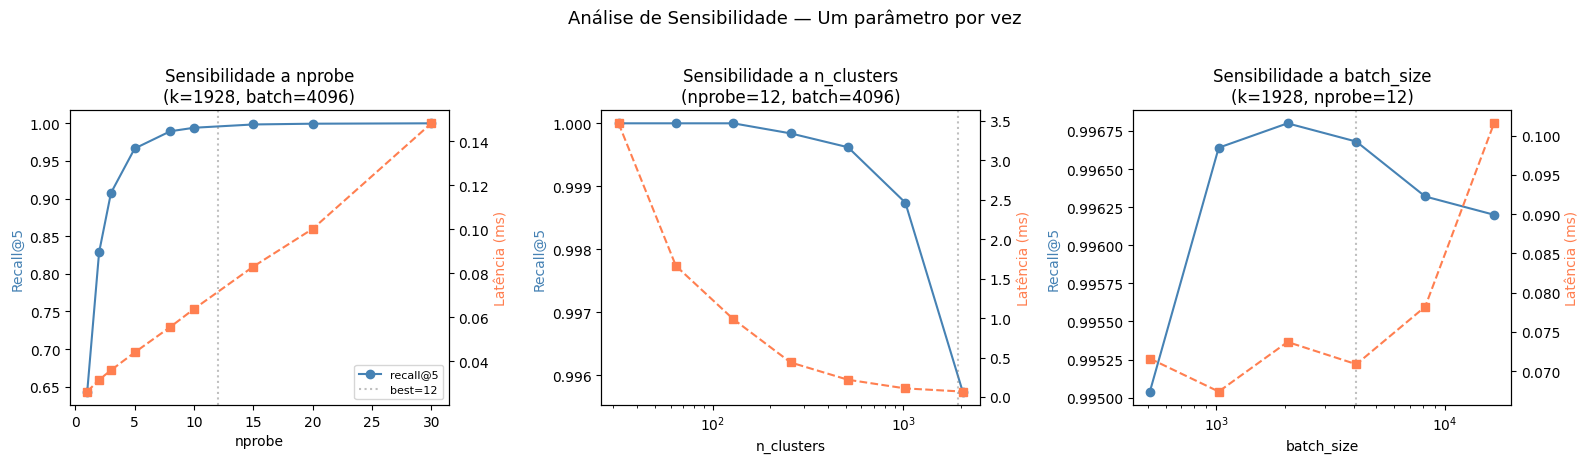

In [23]:
# Análise de sensibilidade: fixar 2 parâmetros e variar o terceiro
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1) Efeito do nprobe (fixando n_clusters e batch_size do melhor)
nprobe_range = sorted(set([1, 2, 3, 5, 8, 10, 15, 20, 30]) & set(range(1, best_n_clusters + 1)))
experiment.build_index(best_n_clusters, best_batch_size)
sens_nprobe = [experiment.search(n) for n in nprobe_range]

ax = axes[0]
ax.plot(nprobe_range, [r["recall_at_k"] for r in sens_nprobe], "o-", color="steelblue", label="recall@5")
ax.set_xlabel("nprobe")
ax.set_ylabel("Recall@5", color="steelblue")
ax2 = ax.twinx()
ax2.plot(nprobe_range, [r["latency_ms"] for r in sens_nprobe], "s--", color="coral", label="latência")
ax2.set_ylabel("Latência (ms)", color="coral")
ax.set_title(f"Sensibilidade a nprobe\n(k={best_n_clusters}, batch={best_batch_size})")
ax.axvline(best_nprobe, color="gray", linestyle=":", alpha=0.5, label=f"best={best_nprobe}")
ax.legend(loc="lower right", fontsize=8)

# 2) Efeito do n_clusters (fixando nprobe e batch_size do melhor)
k_range = [32, 64, 128, 256, 512, 1024, 2048]
sens_k = []
for k_val in k_range:
    experiment.build_index(k_val, best_batch_size)
    nprobe_capped = min(best_nprobe, k_val)
    sens_k.append(experiment.search(nprobe_capped))

ax = axes[1]
ax.plot(k_range, [r["recall_at_k"] for r in sens_k], "o-", color="steelblue")
ax.set_xlabel("n_clusters")
ax.set_ylabel("Recall@5", color="steelblue")
ax.set_xscale("log")
ax2 = ax.twinx()
ax2.plot(k_range, [r["latency_ms"] for r in sens_k], "s--", color="coral")
ax2.set_ylabel("Latência (ms)", color="coral")
ax.set_title(f"Sensibilidade a n_clusters\n(nprobe={best_nprobe}, batch={best_batch_size})")
ax.axvline(best_n_clusters, color="gray", linestyle=":", alpha=0.5)

# 3) Efeito do batch_size (fixando n_clusters e nprobe do melhor)
batch_range = [512, 1024, 2048, 4096, 8192, 16384]
sens_batch = []
for b in batch_range:
    experiment.build_index(best_n_clusters, b)
    sens_batch.append(experiment.search(best_nprobe))

ax = axes[2]
ax.plot(batch_range, [r["recall_at_k"] for r in sens_batch], "o-", color="steelblue")
ax.set_xlabel("batch_size")
ax.set_ylabel("Recall@5", color="steelblue")
ax.set_xscale("log")
ax2 = ax.twinx()
ax2.plot(batch_range, [r["latency_ms"] for r in sens_batch], "s--", color="coral")
ax2.set_ylabel("Latência (ms)", color="coral")
ax.set_title(f"Sensibilidade a batch_size\n(k={best_n_clusters}, nprobe={best_nprobe})")
ax.axvline(best_batch_size, color="gray", linestyle=":", alpha=0.5)

plt.suptitle("Análise de Sensibilidade — Um parâmetro por vez", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Config final para exportação

Parâmetros otimizados para usar na API Go.

In [24]:
config = {
    "n_clusters": best_n_clusters,
    "batch_size": best_batch_size,
    "nprobe": best_nprobe,
    "k_neighbors": K_NEIGHBORS,
    "fraud_threshold": FRAUD_THRESHOLD,
    "recall_at_5": round(search_final["recall_at_k"], 4),
    "latency_ms": round(search_final["latency_ms"], 2),
    "decision_agreement": round(cls_final["decision_agreement"], 4),
    "dataset_size": len(vectors),
    "vector_dim": vectors.shape[1],
}

print(json.dumps(config, indent=2))

# Salvar config
config_path = Path.cwd()
if config_path.name == "notebooks":
    config_path = config_path.parent
config_path = config_path / "data" / "ivf_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print(f"\nConfig salva em {config_path}")

{
  "n_clusters": 1928,
  "batch_size": 4096,
  "nprobe": 12,
  "k_neighbors": 5,
  "fraud_threshold": 0.6,
  "recall_at_5": 0.9967,
  "latency_ms": 0.1,
  "decision_agreement": 0.9997,
  "dataset_size": 100000,
  "vector_dim": 14
}

Config salva em /home/luiz/hobbies/rbc-2026/data/ivf_config.json


## 11. Exportar índice IVF em binário para o Go

Os centroides vêm do Optuna (treinados nos 100k). O índice final usa os **3M vetores completos**.

**`data/centroids.bin`**
```
[int64: n_clusters][int64: dim][float64 × n_clusters × dim]
```

**`data/vectors.bin`**
```
[int64: n_vectors][int64: dim]
[float64 × n_vectors × dim]   ← todos os vetores
[uint8  × n_vectors]          ← labels (1=fraud, 0=legit)
```

**`data/ivf_structure.bin`**
```
[int64: n_clusters]
para cada cluster:
  [int64: list_size]
  [int32 × list_size]          ← índices em vectors.bin (0-based)
```

O Go carrega `vectors.bin` uma vez na RAM, e usa `ivf_structure.bin` para saber quais índices pertencem a cada centroide.

In [ ]:
import struct

data_dir = Path.cwd()
if data_dir.name == "notebooks":
    data_dir = data_dir.parent
data_dir = data_dir / "data"

# ── Centroides (resultado do Optuna, treino nos 100k) ─────────────────────────
experiment.build_index(best_n_clusters, best_batch_size)
centroids = experiment.centroids       # (n_clusters, dim)
n_clusters, dim = centroids.shape

centroids_path = data_dir / "centroids.bin"
with open(centroids_path, "wb") as f:
    f.write(struct.pack("<qq", n_clusters, dim))
    f.write(centroids.astype("<f8").tobytes())

print(f"centroids.bin: {centroids_path.stat().st_size / 1024:.1f} KB  ({n_clusters} centroides × {dim} dims)")

# ── Stream dos 3M: atribui cada vetor ao centroide mais próximo ───────────────
BATCH = 10_000
inv_lists = [[] for _ in range(n_clusters)]

all_vecs_chunks = []
all_labels_list = []
n_total = 0

print(f"\nStreaming {DATA_PATH} (todos os registros)...")
t0 = time.time()

with gzip.open(DATA_PATH, "rb") as gz:
    batch_vecs = []

    def _flush(batch_vecs, offset):
        arr = np.stack(batch_vecs)                         # (BATCH, dim)
        dists = cdist(arr, centroids)                      # (BATCH, n_clusters)
        assignments = np.argmin(dists, axis=1)             # (BATCH,)
        for local_i, c in enumerate(assignments):
            inv_lists[c].append(offset + local_i)
        all_vecs_chunks.append(arr)

    for obj in ijson.items(gz, "item"):
        vec = np.asarray(obj["vector"], dtype=np.float64)
        all_labels_list.append(np.uint8(1 if obj.get("label") == "fraud" else 0))
        batch_vecs.append(vec)

        if len(batch_vecs) == BATCH:
            _flush(batch_vecs, n_total)
            n_total += BATCH
            batch_vecs = []

    if batch_vecs:
        _flush(batch_vecs, n_total)
        n_total += len(batch_vecs)

all_vecs = np.concatenate(all_vecs_chunks)       # (n_total, dim)
all_labels = np.array(all_labels_list, dtype=np.uint8)
elapsed = time.time() - t0
print(f"Stream concluído: {n_total:,} vetores em {elapsed:.1f}s  ({all_vecs.nbytes/1024**2:.0f} MB)")

# ── Salva vectors.bin ─────────────────────────────────────────────────────────
vectors_path = data_dir / "vectors.bin"
with open(vectors_path, "wb") as f:
    f.write(struct.pack("<qq", n_total, dim))
    f.write(all_vecs.astype("<f8").tobytes())
    f.write(all_labels.tobytes())

print(f"vectors.bin: {vectors_path.stat().st_size / 1024**2:.1f} MB  ({n_total:,} vetores)")

# ── Salva ivf_structure.bin ───────────────────────────────────────────────────
ivf_path = data_dir / "ivf_structure.bin"
with open(ivf_path, "wb") as f:
    f.write(struct.pack("<q", n_clusters))
    for c in range(n_clusters):
        ids = np.array(inv_lists[c], dtype="<i4")   # int32 índices
        f.write(struct.pack("<q", len(ids)))
        f.write(ids.tobytes())

sizes = [len(inv_lists[c]) for c in range(n_clusters)]
print(f"ivf_structure.bin: {ivf_path.stat().st_size / 1024**2:.1f} MB")
print(f"  Tamanho médio das listas: {np.mean(sizes):.0f}  (min={np.min(sizes)}, max={np.max(sizes)})")

# ── Sumário ───────────────────────────────────────────────────────────────────
print(f"\nArquivos em {data_dir}:")
for p in [centroids_path, vectors_path, ivf_path, data_dir / "ivf_config.json"]:
    sz = p.stat().st_size
    print(f"  {p.name:<25} {sz/1024**2:7.1f} MB")